# 비지도학습

1. 비지도학습 - 정답이 없는 문제.
2. K-Means 군집화
3. k를 정하는 방법 - 엘보, 실루엣 & DBI
4. PCA 차원축소
5. GridSearchCV - 최적화 도구


In [3]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import setup
from _ml import build_dataset, FEATURES, SEED, time_split, load_merged

setup()
pd.set_option("display.width", 130)
      
print("준비완료")


[폰트] Malgun Gothic / unicode_minus=False
준비완료


---
# 비지도 학습 - 정답이 없는 문제.

||지도학습|비지도학습|
|---|---|---|
|데이터|입력+정답|입력만|
|목표|정답 맞히기|패턴 발견|
|평가|정답과 비교|사람이 해석|

### 어디다가 사용하는가?

> 군집화 : 비슷한 종목끼리 묶기 -> 포트폴리오 분산  
> 차원 축소 : 피처 750개 -> 5개로 압축  
> 이상탐지 : 평소와 다른 거래 패턴 찾기

### 실습

120개 종목을 수익률 패턴으로 군집화하고 실제 섹터와 비교. -> 섹터끼리 묶이면 성공

In [22]:
# 데이터를 종목 * 날짜 행렬로 만들기
df = load_merged()
df["ret"] = df.groupby("code")["close"].transform(lambda s: s.pct_change())

# 행 = 날짜, 열 = 종목, 값 = 수익률
pivot = df.pivot_table(index="date", columns="code", values="ret")

# 종목별 실제 섹터 (정답은 아니고 학습을 위한 비교 참고자료)
sector = df[["code", "sector"]].drop_duplicates().set_index("code")["sector"]
true_labels = sector[pivot.columns].values

print(f"수익률 행렬 : {pivot.shape}  (날짜 x 종목)")
print(f"군집화 입력 : {pivot.T.shape}  (종목 x 날짜)")
print()
print("종목을 묶을 것이므로 '종목이 해' 되도록 전치(.T)합니다.")
print(f"각 종목이 {pivot.shape[0]}개의 값(날짜별 수익률)으로 표현된다.")
print()
print(f"섹터 {pd.DataFrame(true_labels).value_counts()}종류, 종목 {len(true_labels)}개")



수익률 행렬 : (749, 120)  (날짜 x 종목)
군집화 입력 : (120, 749)  (종목 x 날짜)

종목을 묶을 것이므로 '종목이 해' 되도록 전치(.T)합니다.
각 종목이 749개의 값(날짜별 수익률)으로 표현된다.

섹터 0    
금융       18
전기전자     16
IT서비스    14
유통       12
화학       12
바이오      12
운수장비     12
건설       10
에너지       8
식품        6
Name: count, dtype: int64종류, 종목 120개


---
# K-Means 군집화

1. k개의 중심점을 아무 곳에나 찍는다.  
2. 각 데이터를 가장 가까운 중심점에 배정한다.  
3. 각 그룹의 평균으로 중심점을 옮긴다  
4. 중심점이 안 움직일 때까지 2,3번 반복  

-> K개의 평균을 찾는 알고리즘

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score, davies_bouldin_score

def 군집화(matrix, k=10, scale=True):
    """군집화하고 결과를 돌려준다"""

    M = matrix.T.values     # 행 = 종목
    
    if scale:
        M = StandardScaler().fit_transform(M)

    km = KMeans(
        n_clusters=k,
        random_state=SEED, # 재현성
        n_init=10,  # n번 시도해서 가장 좋은 결과를 고름
    )

    labels = km.fit_predict(M)
    return labels, M, km


# pivot = (날짜 x 종목)
labels, M_scaled, km = 군집화(pivot, k=10, scale=True)

print(f"군집별 종목 수 : ")
# 10개의 그룹에 각각 종목이 몇개씩 균등하게 나누어 들어갔는가?
print(pd.Series(labels).value_counts().sort_index().to_string())

군집별 종목 수 : 
0     5
1    18
2    25
3    14
4     2
5    15
6    13
7     7
8    12
9     9


**random_state, n_init을 둘다 지정하고 해보자**

중심점을 무작위로 찍고 시작하니까, 실행마다 다른군집이 나올 수 있음.  
- random_state=42 : 랜덤시드를 동일하게 주어, 항상 같은 곳을 찍게함.  
- n_init=10 : 여러 번 시도해서 가장 좋은 결과를 고름. 

---
# 스케일링을 하느냐 마느냐

> 120개 종목을 수익률로 군집화하고 실제 섹터와 비교해보자. -> 같은 섹터끼리 묶이면 성공  
> -> 해보니까 잘 안나온다

In [ ]:
# ARI : 두 그룹이 얼마나 일치하는가? 얼마나 비슷하게 잘 묶였는가?
# 1.0 : 완전일치 / 0.0 무작위와 같음
# 정답이 없는 비지도학습이기때문에 원래는 이렇게 구할 수 없지만, 참고자료가 있는 학습데이터이므로 비교가 가능.

# 주가 변동성이나 단위 차이를 조절하지 않고 그대로 군집화
lab_raw, M_raw, _ = 군집화(pivot, k=10, scale=False)

# 모든 종목의 변동성을 평균0, 표준편차 1로 맞춘뒤 군집화
lab_scaled, M_scaled, _ = 군집화(pivot, k=10, scale=True)

vol = pivot.std()

rows = []
for name, lab in [("스케일링 없음", lab_raw), ("StandardScaler 적용", lab_scaled)]:
    # 각 군집의 평균 변동성(위아래 움직임 폭)을 구해 가장 높은 군집과 가장 낮은 군집의 차이
    군집별변동성 = pd.Series(vol.values).groupby(lab).mean()
    
    rows.append({
        "방식": name,
        "ARI(섹터와 일치)" :  adjusted_rand_score(true_labels, lab),
        "군집간 변동성 차이" : 군집별변동성.max() - 군집별변동성.min(),
    })

print(pd.DataFrame(rows).round(4).to_string(index=False))

               방식  ARI(섹터와 일치)  군집간 변동성 차이
          스케일링 없음       0.0333      0.0035
StandardScaler 적용       0.5265      0.0053


**스케일링 없이는 섹터 구분이 전혀 안된다. (ARI 0.03)**

K-Means는 거리로 판단한다. 모든 종목이 시장 흐름에 함께 움직이므로, 공통 성분이 거리를 지배한다. 센터차이는 그 아래에 묻혀있다.  
그런데 StandardScaler를 넣으면 ARI가 0.53으로 뛴다. 왜?

In [ ]:
# StandardScaler가 무엇을 하는지 확인해보자.
# 입력이 (종목 x 날짜)이므로 열은 날짜.
# StandardScaler는 열마다 표준화 -> 날짜마다 표준화 -> 그날의 평균을 뺀다.

M = pivot.T.values # 행 = 종목, 열= 날짜
날짜별_평균 = M.mean(axis=0) #각 날짜의 전 종목 평균
시장수익률 = pivot.mean(axis=1).values # 그날의 시장 수익률

print(f"StandardScaler가 빼는 값 : {np.round(날짜별_평균[:5], 6)}")
print(f"그날의 시장 수익률 : {np.round(시장수익률[:5], 6)}")
print()

# StandardScaler가 제거하는 값은 실제로 시장 수익률과 같다.
# 스케일링이 곧 시장요인을 제거하는 것과 같다.

StandardScaler가 빼는 값 : [-0.011917  0.003916  0.001092 -0.012078  0.007979]
그날의 시장 수익률 : [-0.011917  0.003916  0.001092 -0.012078  0.007979]



**K-Means 또한 입력피처를 변경하면 성능이 좋아진다**

In [26]:
# 군집과 섹터가 얼마나 겹치는지 확인.

교차표 = pd.crosstab(pd.Series(lab_scaled, name="군집"),
                    pd.Series(true_labels, name="섹터"),)
print(교차표.to_string())
print()
most = 교차표.max(axis=1).sum()
print(f"각 군집에서 가장 많은 섹터가 차지하는 비율 : {most/교차표.values.sum():.1f}")

섹터  IT서비스  건설  금융  바이오  식품  에너지  운수장비  유통  전기전자  화학
군집                                                 
0       0   0   0    2   0    0     2   0     0   1
1       0   1  16    0   1    0     0   0     0   0
2      14   0   0    1   0    0     5   1     3   1
3       0   9   1    0   0    0     2   1     0   1
4       0   0   0    0   1    1     0   0     0   0
5       0   0   0    2   0    0     1   0    12   0
6       0   0   0    0   1    0     1  10     1   0
7       0   0   0    7   0    0     0   0     0   0
8       0   0   1    0   3    7     1   0     0   0
9       0   0   0    0   0    0     0   0     0   9

각 군집에서 가장 많은 섹터가 차지하는 비율 : 0.7


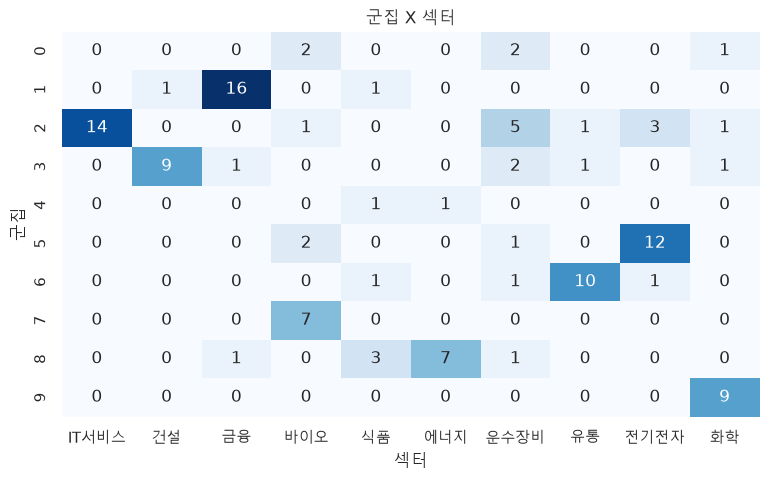

In [27]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(9,5))
sns.heatmap(교차표, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("군집 X 섹터")
plt.show()

---
# K를 어떻게 정할것인가?

|방법|보는 것|방향|
|---|---|---|
|엘보|K를 늘릴수록 오차가 줄어듬, 꺽이는 지점|-|
|실루엣 계수|군집 안은 뭉치고 간은 떨어졌는가|높을 수록 좋음|
|DBI|군집끼리 잘 분리 되었는가?|낮을수록 좋음|

    
> 실루엣은 높을수록, DBI는 낮을수록 좋다.

In [31]:
ks = range(2, 16)
rows = []

for k in ks:
    # k수를 변경해가며 KMeans모델을 생성 -> 군집화 실행
    km_k = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(M_scaled)
    lab_k = km_k.labels_
    rows.append({
        "k" : k,
        "관성" : km_k.inertia_, # 엘보확인용 - 낮을수록 좋음(감소폭이 둔화되는 지점)
        "실루엣" : silhouette_score(M_scaled, lab_k), # 높을수록 좋음(군집간 분리도와 내부 응집도를 종합 -  1에 가까운 값)
        "DBI" : davies_bouldin_score(M_scaled, lab_k), # 낮을수록 좋음(데이비스-볼딘 지수 -> 0에 가장 가까운 최저점)
        "ARI(참고)" : adjusted_rand_score(true_labels, lab_k), # 실제 정답과 얼마나 유사한가(유사하면 1)
    })

k_table = pd.DataFrame(rows)
print(k_table.round(4).to_string(index=False))

 k         관성    실루엣    DBI  ARI(참고)
 2 86829.6581 0.0249 5.3262   0.1593
 3 85487.7156 0.0163 5.0055   0.2217
 4 84580.5442 0.0139 5.1342   0.2523
 5 83066.5696 0.0134 4.7518   0.2501
 6 82233.8038 0.0084 4.6291   0.2950
 7 80815.0873 0.0141 4.5523   0.4656
 8 80265.0721 0.0089 4.4493   0.4634
 9 79205.4191 0.0027 3.7824   0.4252
10 77600.6181 0.0147 3.7209   0.5265
11 77306.6468 0.0075 3.7116   0.4172
12 76122.9891 0.0047 3.6581   0.4532
13 74993.5229 0.0154 3.3516   0.5808
14 74657.9752 0.0018 3.5112   0.3796
15 73741.1954 0.0054 3.0951   0.5034


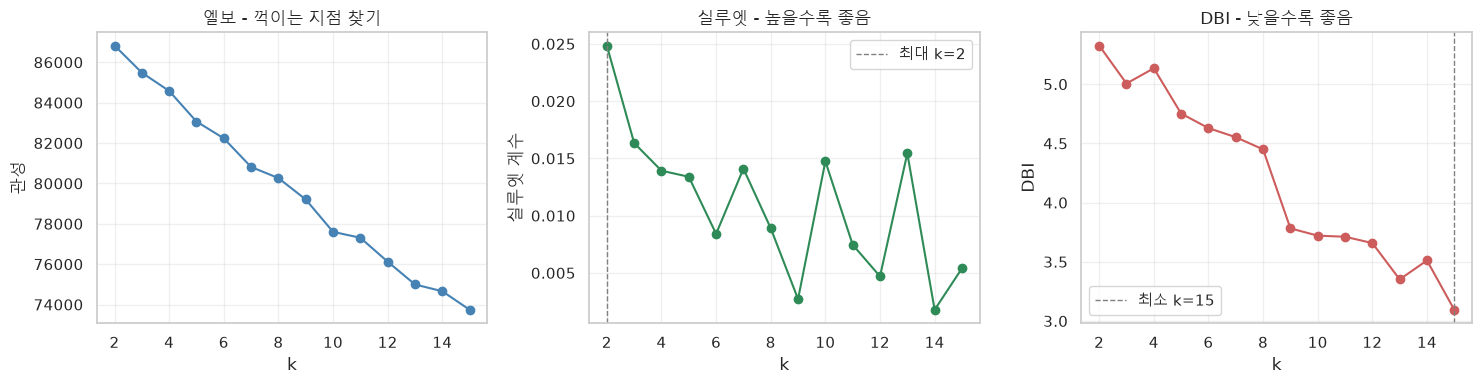

In [32]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

# 엘보
axes[0].plot(k_table["k"], k_table["관성"], "o-", color="steelblue")
axes[0].set_xlabel("k")
axes[0].set_ylabel("관성")
axes[0].set_title("엘보 - 꺽이는 지점 찾기")
axes[0].grid(alpha=0.3)

#실루엣
best_sil = k_table.loc[k_table["실루엣"].idxmax(), "k"]
axes[1].plot(k_table["k"], k_table["실루엣"], "o-", color="seagreen")
axes[1].axvline(best_sil, color="gray", ls="--", lw=1, label=f"최대 k={best_sil}")
axes[1].set_xlabel("k")
axes[1].set_ylabel("실루엣 계수")
axes[1].set_title("실루엣 - 높을수록 좋음")
axes[1].legend()
axes[1].grid(alpha=0.3)

# DBI
best_dbi = k_table.loc[k_table["DBI"].idxmin(), "k"]
axes[2].plot(k_table["k"], k_table["DBI"], "o-", color="indianred")
axes[2].axvline(best_dbi, color="gray", ls="--", lw=1, label=f"최소 k={best_dbi}")
axes[2].set_xlabel("k")
axes[2].set_ylabel("DBI")
axes[2].set_title("DBI - 낮을수록 좋음")
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [34]:
best_ari = k_table.loc[k_table["ARI(참고)"].idxmax(), "k"]

print(f"실루엣 (최대) : {best_sil}")
print(f"DBI (최소) : {best_dbi}")
print(f"ARI (최대, 참고용) : {best_ari}")

실루엣 (최대) : 2
DBI (최소) : 15
ARI (최대, 참고용) : 13


**1. 엘보가 뚜렸하지 않다**
> 관성곡선이 완만하게 내려가기만해서 어디가 팔꿈치인지 알수 없다. -> 일반적으로 이렇게 된다.

**2. 실루엣이 매우 낮다(0.02수준)**
> 군집이 뚜렷하게 나뉘지않는다. -> 금융 수익률 데이터에서는 일반적이다.

**3. 모든 지표가 다른 K가 좋다고한다.**
> 실루엣이 작은 k, DBI가 큰k가 각각있다. 어느 하나를 기계적으로 믿으면 안된다.  
> 결국 도메인 지식으로 정해야한다. -> 섹터가 10개니까 k=10

**K-Means는 무슨 데이터를 줘도 k개로 나눈다**
의미가 없어도 나눈다. 군집화는 군집 k개가 결국 어떤것이다라는 해석을 할 수 없으면 쓸모가 없음.

---
# 정리
|개념|핵심|
|---|---|
|비지도학습|정답이 없으니 결과를 사람이 직접 해석해야한다.|
|K-Means|random_state와 n_init을 둘다 지정 사용|
|스케일링|데이터에서 외부요인을 제거해주는 역할|
|k정하기|엘보,실루엣,DBI를 확인하고 사람이 정한다.|
|DBI|낮을수록 좋다(실루엣과 반대)|